# Initial Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 8* 0.0416667 # 1 hour to days

In [4]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [5]:
TOI_id = 'TOI 1408'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)


SearchResult containing 18 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 16 2019   SPOC     120   364186197      0.0
  1 TESS Sector 17 2019   SPOC     120   364186197      0.0
  2 TESS Sector 18 2019   SPOC     120   364186197      0.0
  3 TESS Sector 19 2019   SPOC     120   364186197      0.0
  4 TESS Sector 24 2020   SPOC     120   364186197      0.0
  5 TESS Sector 25 2020   SPOC     120   364186197      0.0
  6 TESS Sector 59 2022   SPOC     120   364186197      0.0
  7 TESS Sector 58 2022   SPOC     120   364186197      0.0
  8 TESS Sector 52 2022   SPOC     120   364186197      0.0
  9 TESS Sector 57 2022   SPOC     120   364186197      0.0
 10 TESS Sector 73 2023   SPOC     120   364186197      0.0
 11 TESS Sector 85 2024   SPOC     120   364186197      0.0
 12 TESS Sector 76 2024   SPOC     120   364186197      0

In [6]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 18 objects:
    0: <TessLightCurve LABEL="TIC 364186197" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 364186197" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 364186197" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 364186197" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 364186197" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 364186197" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 364186197" SECTOR=59 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 364186197" SECTOR=58 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 364186197" SECTOR=52 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 364186197" SECTOR=57 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 364186197

In [7]:
clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [8]:
# Normalize, flatten, and remove outliers
processed_lcs = [
    lc.normalize().flatten(window_length=401).remove_outliers(sigma=5)
    for lc in clean_lcs
]

In [9]:
# Stitch into one combined light curve
combined_lc = processed_lcs[0]
for lc in processed_lcs[1:]:
    combined_lc = combined_lc.append(lc)



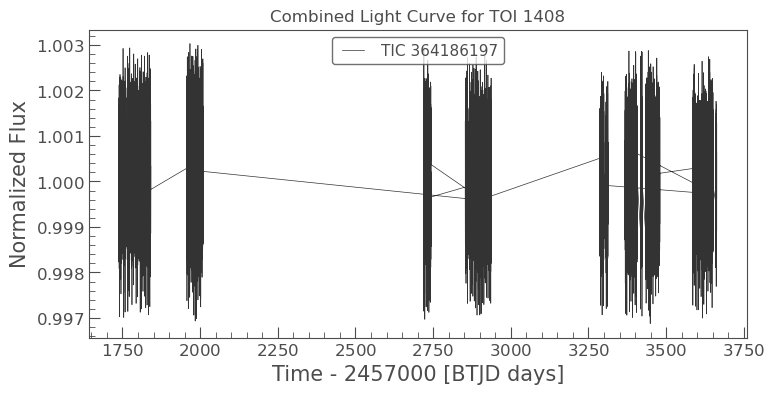

In [10]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [11]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1738.65487455 1738.65626347 1738.65765239 ... 3662.8244768  3662.82586566
 3662.82725451]
[1.00018616 1.00023157 0.99979227 ... 1.00045466 0.99969386 1.00063077]


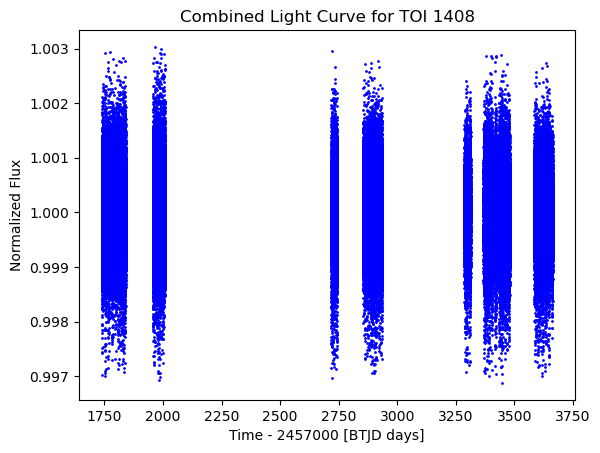

In [12]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 133287 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


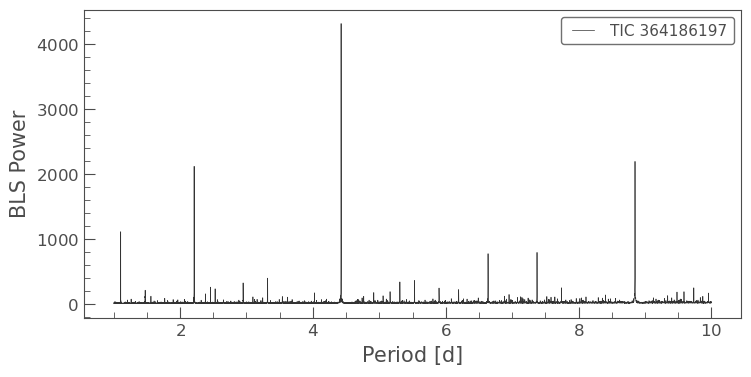

In [13]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 10, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [14]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 4.42484 days
Best candidate t0: 1740.81987 days
Best candidate dur: 0.05000 days


In [15]:
import numpy as np
from scipy.signal import find_peaks

# 1. Access full power array
powers = bls_1.power.value
periods = bls_1.period.value
durations = bls_1.duration.value
t0s = bls_1.transit_time.value

# 2. Find all peaks in the BLS power spectrum
peaks, _ = find_peaks(powers)

# 3. Sort peaks by power (descending)
sorted_peaks = peaks[np.argsort(powers[peaks])[::-1]]

# 4. Get top 3 signal indices
top_indices = sorted_peaks[:7]

# 5. Extract their periods, durations, and t0s
top_periods = periods[top_indices]
top_durations = durations[top_indices]
top_t0s = t0s[top_indices]
top_powers = powers[top_indices]

# 6. Print results
for i in range(7):
    print(f"Signal {i+1}:")
    print(f"  Period:   {top_periods[i]:.5f} days")
    print(f"  T0:       {top_t0s[i]:.5f}")
    print(f"  Duration: {top_durations[i]:.5f} days")
    print(f"  Power:    {top_powers[i]:.5f}")
    print("-" * 30)


Signal 1:
  Period:   4.42484 days
  T0:       1740.81987
  Duration: 0.05000 days
  Power:    4315.35393
------------------------------
Signal 2:
  Period:   8.84968 days
  T0:       1745.24487
  Duration: 0.05000 days
  Power:    2191.84434
------------------------------
Signal 3:
  Period:   2.21242 days
  T0:       1740.81987
  Duration: 0.05000 days
  Power:    2116.82759
------------------------------
Signal 4:
  Period:   1.10621 days
  T0:       1739.71987
  Duration: 0.10000 days
  Power:    1108.55736
------------------------------
Signal 5:
  Period:   7.37444 days
  T0:       1740.86987
  Duration: 0.05000 days
  Power:    789.96804
------------------------------
Signal 6:
  Period:   6.63726 days
  T0:       1743.02487
  Duration: 0.05000 days
  Power:    770.55965
------------------------------
Signal 7:
  Period:   3.31863 days
  T0:       1739.70487
  Duration: 0.05000 days
  Power:    393.55014
------------------------------


In [16]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*2.5)

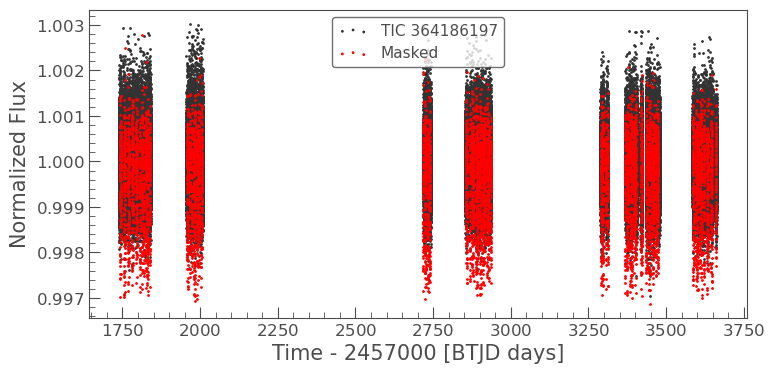

In [17]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [18]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


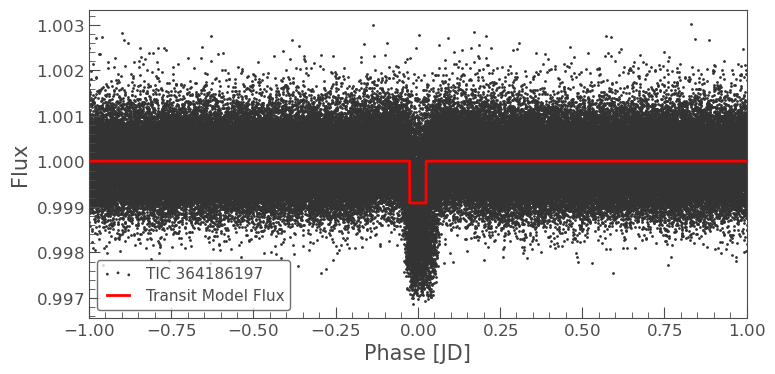

In [19]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 111073 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


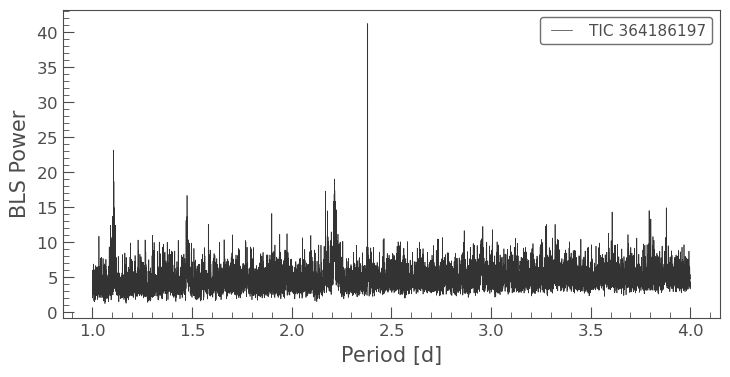

In [20]:
period = np.linspace(1, 4, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [21]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 2.38134 days
Best candidate t0 2: 1741.01987 days


In [22]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [23]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

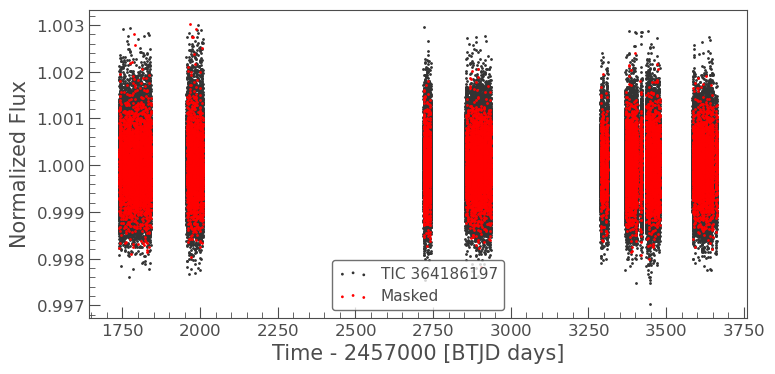

In [24]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [25]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

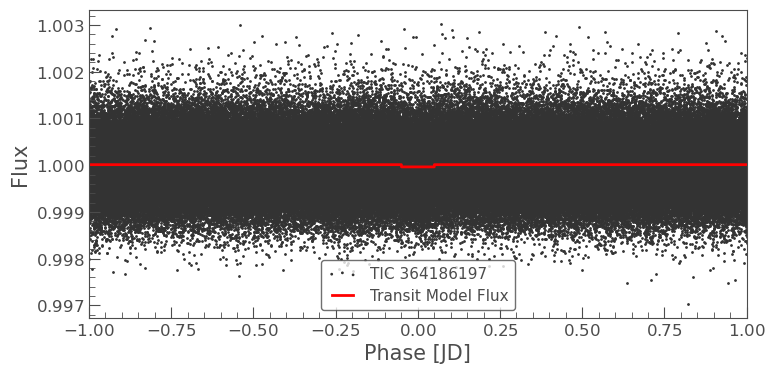

In [26]:
ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## Transit models

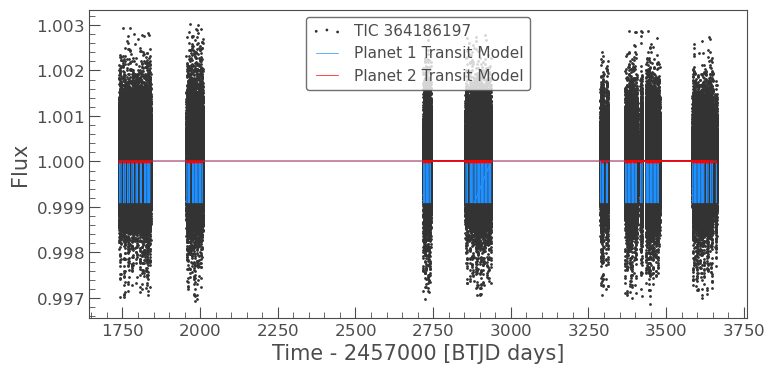

In [27]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
# planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [28]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = planet_1_model.time.value[peaks_1]
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_1, fluxes_1):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1740.81880537 1745.24388641 1754.09404329 1758.51910406 1767.36781596
 1771.79285288 1780.64291354 1785.06792413 1793.9179295  1798.3415239
 1807.1914733  1811.61642958 1820.4663248  1824.89125595 1829.31618873
 1833.74110293 1838.16601214 1957.63696648 1962.06193634 1966.48691863
 1975.33691204 1979.76192083 1984.18555541 1988.61196768 1993.0370026
 1997.46066268 2001.88571113 2006.30938132 2913.40335786 2917.82690962
 2922.25184481 2926.67676174 2931.10167936 2935.5265929  2882.44104139
 2886.85353886 2891.27853423 2895.70352078 2900.12848901 2904.55206732
 2908.97702749 2718.70885396 2723.13388562 2727.55893177 2731.98398263
 2736.40903985 2740.8341097  2855.87972531 2860.30616923 2869.15347738
 2873.57711611 2878.00352877 3289.51552321 3293.94044604 3298.36397559
 3307.21377594 3311.63867669 3612.52774169 3616.95413034 3621.37774267
 3630.22630573 3634.65266875 3369.16212231 3373.58562262 3378.01052559
 3382.43542761 3386.86171951 3391.285250

In [29]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = planet_2_model.time.value[peaks_2]
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1741.01880912 1743.40079749 1745.78139609 1752.92735955 1755.30656045
 1757.68853744 1760.07051337 1764.83445758 1767.2150368  1769.59700191
 1771.97618764 1774.35953924 1779.11929707 1781.50124943 1783.88319964
 1786.26514838 1791.02765846 1793.40820879 1795.79014536 1798.17069131
 1800.55262532 1805.31510103 1807.69702415 1810.07755645 1812.45530975
 1817.2233161  1819.60383765 1821.98435721 1824.36626429 1826.74678215
 1829.12869201 1831.51198052 1833.89109991 1836.27438461 1838.65350205
 1841.03678716 1957.73557681 1960.1022261  1962.48415629 1964.86470123
 1967.24663943 1969.627195   1972.00774678 1974.38968957 1976.77163569
 1979.15358547 1981.53553986 1983.9161098  1986.29528749 1988.70224605
 1991.05920763 1993.44117314 1998.20372574 2000.58569587 2002.96628007
 2005.34825636 2007.72884753 2912.63809025 2915.01861427 2917.40052661
 2919.78104869 2922.1518464  2926.92536822 2929.30726851 2931.68777937
 2934.0696778  2936.45157305 2884.0618

In [30]:
# ### remove transit times that are too close to planet 1 
# threshold = 0.25
# # Use broadcasting to calculate all absolute time differences
# diff_matrix = np.abs(transit_times_2[:, None] - transit_times_1[None, :])

# # Find which planet 2 transits are too close to any planet 1 transit
# too_close = np.any(diff_matrix < threshold, axis=1)

# # Keep only those that are not too close
# filtered_t2 = transit_times_2[~too_close]

# # Print results
# print(filtered_t2)
# transit_times_2 = filtered_t2

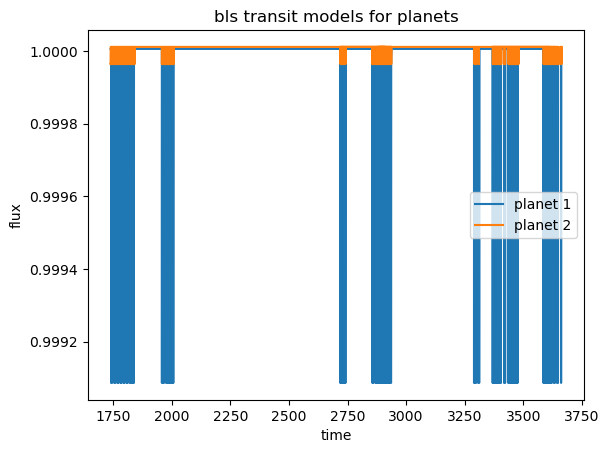

In [31]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
# plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [32]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [33]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [34]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        ### fit parabola to the chisq
        p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        ### Extract the coefficients   y = ax^2 + bx + c
        a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        ### Calculate the minimum chi-squared value
        chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        tc_chi_parabola[j] = tc_best_fit
    
        ### Calculate the parabola best fit 
        p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        ### calculate ttv from parabola fit 
        ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # # Find the intersection using root_scalar
        # intersections = []
        # for k in range(len(tc1) - 1):
        #     if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections.append((sol.root - min_chi_time))
        # errors.append(intersections)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(time, flux, transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [36]:
### stellar params
q1 = 0.5
q2 = 0.84

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

1.1879393923933999
-0.4808326112068523


## Planet 1

In [37]:
### Planet params 
### the params given did not match the depth of the transit in the data
per_1=  4.42587
# per_1 = 0.15
rp_1= 0.08
b_1=  0.999999999999
T14_1= 1.65 * 0.0416667  # convert to days from hours 
# T14_1 = planet_1_dur.value * 0.0416667  # convert to days from hours 

In [38]:
ttv_hour = 2* 0.0416667 # 1 hour to days

tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [39]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []

In [40]:
tc_chi_1, ttv_1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [41]:
print(tc_chi_1)
print(np.sort(tc_chi_1))

[1740.85859519 1745.28667924 1754.13600195 1758.56173005 1767.41344496
 1771.83381054 1780.68604004 1785.11121746 1793.96189016 1798.38298206
 1807.22892745 1811.6542174  1820.50110961 1824.92253725 1829.3453012
 1833.77471991 1838.19579195 1957.66691312 1962.08837947 1966.51386226
 1975.360519   1979.78919813 1984.21166487 1988.63991231 1993.06311206
 1997.48910781 2001.91132009 2006.33949479 2913.40510961 2917.82982921
 2922.25176139 2926.67934766 2931.10326428 2935.52384015 2882.4401238
 2886.86196396 2891.28462366 2895.71177904 2900.13474527 2904.55965825
 2908.98161542 2718.7189474  2723.14514689 2727.57102721 2731.99641174
 2736.42180262 2740.84637197 2855.88381274 2860.31659634 2869.16206931
 2873.58821055 2878.01612471 3289.50759861 3293.93502395 3298.36022183
 3307.21135685 3311.63158626 3612.50863924 3616.92952238 3621.35530354
 3630.20386661 3634.62772712 3369.14735754 3373.57152517 3377.99509348
 3382.422498   3386.84428539 3391.27098648 3395.69657927 3400.12316971
 3404.54

In [42]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = np.sort(tc_chi_1)

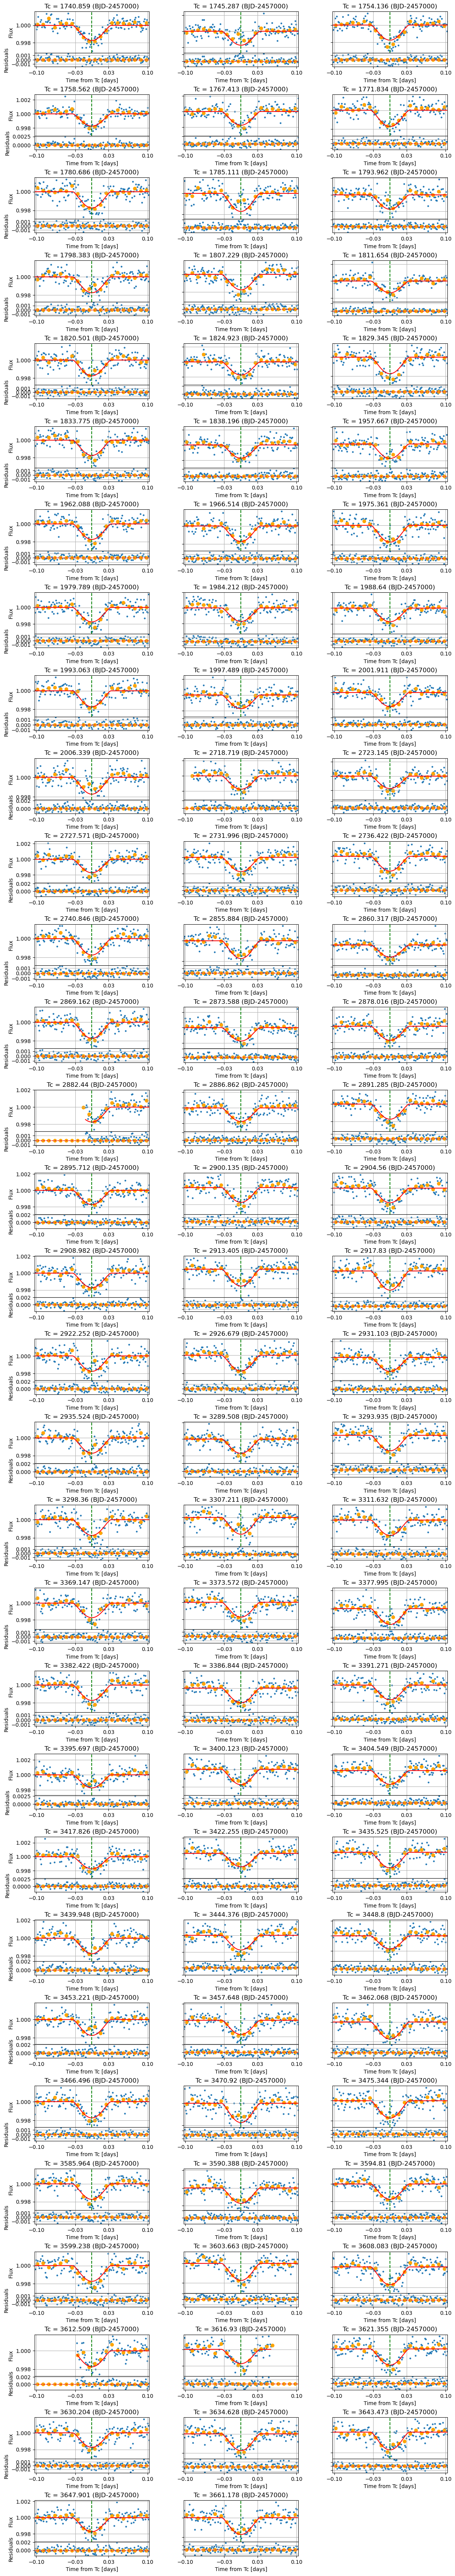

In [43]:
plot_transits(time, flux, transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

## Planet 2

In [44]:
### Planet params (from barros et al 2022)
# planet b
per_2=  2.1664
rp_2=  0.0134
b_2=  0.73
T14_2= 2.67* 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [45]:
ttv_hour = 8.5* 0.0416667 # 1 hour to days

tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [46]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []

In [47]:
tc_chi_2, ttv_2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [48]:
print(tc_chi_2)

[1740.85821089 1743.61386489 1746.07033109 1752.88446245 1755.07718506
 1757.68889196 1760.3665388  1764.64195242 1767.41392335 1769.27686902
 1771.83969687 1774.08265797 1779.1231968  1781.27400117 1783.87788181
 1786.61577011 1791.37615306 1793.39225532 1795.85218661 1798.37099594
 1800.59552242 1805.04814636 1807.70376006 1810.15165144 1812.74708093
 1817.23005201 1819.69140445 1821.8719739  1824.1468155  1827.1009491
 1829.33821419 1831.1599407  1833.78580703 1836.2924652  1838.72901512
 1841.00168953 1957.66715417 1959.98842471 1962.41786077 1964.87852757
 1967.26117481 1969.27302805 1971.68265059 1974.13124342 1976.52595231
 1979.43117578 1981.87268978 1984.21213523 1986.6338555  1988.65225852
 1991.29567345 1993.42592872 1998.55009322 2000.93986282 2002.95245373
 2005.65137222 2007.79230687 2912.35908185 2915.08987309 2917.33706727
 2919.53820148 2922.27415631 2926.67543059 2929.35229274 2931.80228981
 2934.05443338 2936.43632862 2884.08562629 2886.08826099 2888.81911139
 2891.2

In [60]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = np.sort(tc_chi_2)

In [64]:
### masked lightcurve 
time_mask = masked_lc_1.time.value
flux_mask = masked_lc_1.flux.value

# Find gaps in the lightcurve — where time jumps by more than expected cadence
time_diffs = np.diff(time_mask)
median_dt = np.median(time_diffs)
gap_threshold = 10 * median_dt  # customize as needed

# Times that define the centers of gaps
gap_indices = np.where(time_diffs > gap_threshold)[0]
gap_centers = (time_mask[gap_indices] + time_mask[gap_indices + 1]) / 2

# You can optionally define a gap region (start, end) if you want a wider mask:
gap_starts = time_mask[gap_indices]
gap_ends = time_mask[gap_indices + 1]

# Remove transit times that fall too close to any gap center
safe_transit_times = []
for tc in tc_chi_2:
    too_close = np.any(np.abs(tc - gap_centers) < buffer)
    if not too_close:
        safe_transit_times.append(tc)

safe_transit_times = np.array(np.sort(safe_transit_times))


In [65]:
print(safe_transit_times)

[1743.61386489 1746.07033109 1752.88446245 1755.07718506 1757.68889196
 1760.3665388  1764.64195242 1769.27686902 1774.08265797 1779.1231968
 1781.27400117 1783.87788181 1786.61577011 1793.39225532 1795.85218661
 1800.59552242 1805.04814636 1807.70376006 1810.15165144 1812.74708093
 1817.23005201 1819.69140445 1821.8719739  1824.1468155  1827.1009491
 1831.1599407  1836.2924652  1838.72901512 1841.00168953 1959.98842471
 1962.41786077 1964.87852757 1967.26117481 1969.27302805 1971.68265059
 1974.13124342 1976.52595231 1979.43117578 1981.87268978 1986.6338555
 1991.29567345 1993.42592872 1998.55009322 2000.93986282 2002.95245373
 2005.65137222 2007.79230687 2719.78494381 2721.77976829 2724.49501403
 2726.91598121 2729.2916017  2733.77337536 2738.81459856 2855.48066718
 2857.6187307  2862.61030904 2870.02286327 2871.82269852 2876.94116537
 2879.15082316 2881.36617844 2884.08562629 2886.08826099 2888.81911139
 2893.92259422 2898.3425989  2900.46572598 2903.12633614 2905.7004123
 2907.9242



In [66]:
# plot_transits(time_mask, flux_mask, transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)
plot_transits(time_mask, flux_mask, safe_transit_times, per_2, rp_2, b_2, T14_2, u1, u2)

In [67]:
### remove overlapping transits and incomplete transits
# Indices to remove 2
values_to_remove = [1764.64230694, 1969.24572989, 3610.50600897, 3612.48404344]
# indices_to_remove_2 = [12, 29, 75, 100,105, 124,126,136]
# Create boolean masks for values to remove
mask_tc_chi_2 = np.isin(tc_chi_2, values_to_remove)
mask_ttv_2 = np.isin(ttv_2, values_to_remove)

# Remove values from tc_chi_2 and ttv_2 based on masks
tc_chi_2 = tc_chi_2[~mask_tc_chi_2]
ttv_2 = ttv_2[~mask_ttv_2]

In [68]:

print(tc_chi_2)
print(ttv_2)
print(tc_chi_1)
print(ttv_1)

[1740.85821089 1743.61386489 1746.07033109 1752.88446245 1755.07718506
 1757.68889196 1760.3665388  1764.64195242 1767.41392335 1769.27686902
 1771.83969687 1774.08265797 1779.1231968  1781.27400117 1783.87788181
 1786.61577011 1791.37615306 1793.39225532 1795.85218661 1798.37099594
 1800.59552242 1805.04814636 1807.70376006 1810.15165144 1812.74708093
 1817.23005201 1819.69140445 1821.8719739  1824.1468155  1827.1009491
 1829.33821419 1831.1599407  1833.78580703 1836.2924652  1838.72901512
 1841.00168953 1957.66715417 1959.98842471 1962.41786077 1964.87852757
 1967.26117481 1969.27302805 1971.68265059 1974.13124342 1976.52595231
 1979.43117578 1981.87268978 1984.21213523 1986.6338555  1988.65225852
 1991.29567345 1993.42592872 1998.55009322 2000.93986282 2002.95245373
 2005.65137222 2007.79230687 2912.35908185 2915.08987309 2917.33706727
 2919.53820148 2922.27415631 2926.67543059 2929.35229274 2931.80228981
 2934.05443338 2936.43632862 2884.08562629 2886.08826099 2888.81911139
 2891.2

# O-C

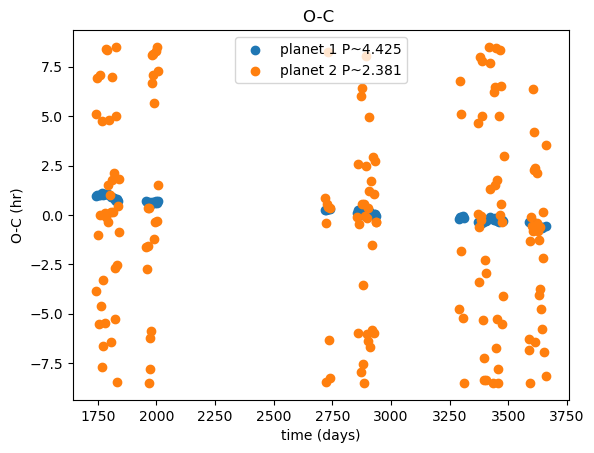

In [71]:
# TTV
## outliers in planet 2, removing for now 
# tc_chi_2 = tc_chi_2[(ttv_2*(24) > -2) & (ttv_2*(24) < 2)]
# ttv_2 = ttv_2[(ttv_2*(24) > -2) & (ttv_2*(24) < 2)]
plt.scatter(tc_chi_1, ttv_1*(24), label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24), label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.title('O-C ')
plt.xlabel('time (days)')
plt.ylabel('O-C (hr)')
# plt.ylim(-0.2,0.2)
plt.legend()
plt.show()

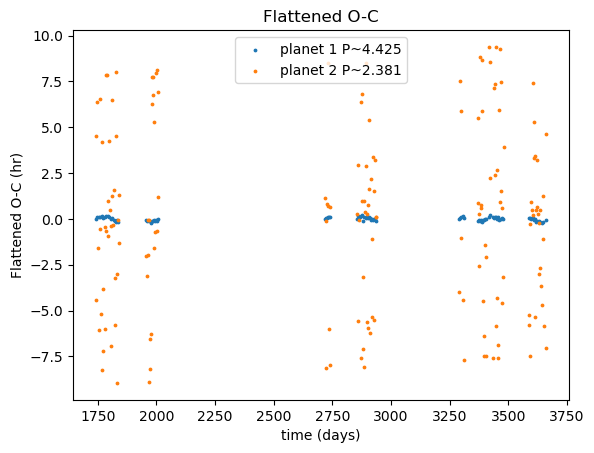

In [80]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24) - linear_fit_1
ttv_2_detrended = ttv_2*(24) - linear_fit_2

# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended, s=3, label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended, s=3, label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (hr)')
plt.legend()
plt.show()

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_1_minutes = ttv_1 * 24

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_1_minutes), 1, 100, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_1, ttv_1_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit = np.linspace(min(tc_chi_1), max(tc_chi_1), 1000)
ttv_fit = model(t_fit, a, b, A, P, phi)

# # Plot data and fit
# plt.scatter(tc_chi_1, ttv_1_minutes, label='planet 1 data')
# plt.plot(t_fit, ttv_fit, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# # Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_2_minutes = ttv_2 * 24 

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_2_minutes), 8, 100, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_2, ttv_2_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
ttv_fit_2 = model(t_fit, a, b, A, P, phi)

# Plot data and fit
# plt.scatter(tc_chi_2, ttv_2_minutes, label='planet 1 data')
# plt.plot(t_fit_2, ttv_fit_2, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


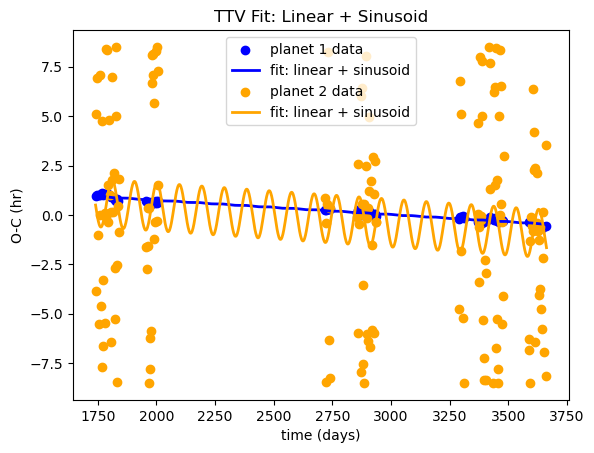

In [77]:
# Plot data and fit
plt.scatter(tc_chi_1, ttv_1_minutes, c='blue',label='planet 1 data')
plt.plot(t_fit, ttv_fit, color='blue', label='fit: linear + sinusoid', linewidth=2)

# Plot data and fit
plt.scatter(tc_chi_2, ttv_2_minutes,c='orange', label='planet 2 data')
plt.plot(t_fit_2, ttv_fit_2, color='orange', label='fit: linear + sinusoid', linewidth=2)
plt.title('TTV Fit: Linear + Sinusoid')
plt.xlabel('time (days)')
plt.ylabel('O-C (hr)')
plt.legend()
plt.show()